# ESN characterization -- Stage 1: memory-capacity sweep

**Question (per Jasper's message, relayed via web):** every decay constant in the two-layer
Hopfield memory (`decay_fast=0.02`, `decay_char=0.0005`, `consolidation_rate=0.01`) was picked
by feel and validated empirically after the fact -- there's no principled sense of "is 0.02 a
fast forgetting rate or a slow one, in some real, comparable sense." Build a minimal Echo State
Network, measure its memory-capacity/spectral-radius tradeoff directly (not guessed), and check
where the existing decay constants would land on that curve as a rough, non-rigorous
sanity-check comparison.

**Falsification criteria, stated before running:** a sane result is a real peaked or monotonic
memory-capacity-vs-spectral-radius tradeoff curve that responds to spectral radius, non-flat,
non-degenerate (memory doesn't vanish at every setting, doesn't blow up at every setting either).
A degenerate result (flat curve, or one that doesn't respond to spectral radius at all) means
something is wrong with the reservoir construction -- root-cause that before concluding anything
about ESNs as a technique.

**Stage 1 only.** Stage 2 (the episodic-layer context-signal follow-up) is explicitly deferred
pending review of this result -- not attempted in this notebook.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parents[1]))

import numpy as np
import matplotlib.pyplot as plt

from src.esn.reservoir import build_reservoir
from src.esn.memory_capacity import memory_capacity

N_UNITS = 300
LEAK_RATE = 0.3
DURATION = 5000
MAX_LAG = 30
N_SEEDS = 5  # per spectral radius, to avoid a single-draw noise artifact looking like a peak
SPECTRAL_RADII = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.5]

print(f"n_units={N_UNITS} leak_rate={LEAK_RATE} duration={DURATION} max_lag={MAX_LAG} "
      f"n_seeds={N_SEEDS} sweep={SPECTRAL_RADII}")

n_units=300 leak_rate=0.3 duration=5000 max_lag=30 n_seeds=5 sweep=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.5]


In [2]:
results = {}  # sr -> list of (mc_per_lag, total_mc) across seeds

for sr in SPECTRAL_RADII:
    per_seed_curves = []
    per_seed_totals = []
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(1000 * seed + int(sr * 1000))
        W_in, W = build_reservoir(N_UNITS, sr, rng=rng)
        mc_per_lag, total_mc = memory_capacity(W_in, W, LEAK_RATE, DURATION, max_lag=MAX_LAG, rng=rng)
        per_seed_curves.append(mc_per_lag)
        per_seed_totals.append(total_mc)
    results[sr] = {
        'mc_per_lag_mean': np.mean(per_seed_curves, axis=0),
        'mc_per_lag_std': np.std(per_seed_curves, axis=0),
        'total_mc_mean': float(np.mean(per_seed_totals)),
        'total_mc_std': float(np.std(per_seed_totals)),
    }
    print(f"sr={sr:.2f}: total_MC = {results[sr]['total_mc_mean']:.2f} +/- {results[sr]['total_mc_std']:.2f}")

sr=0.10: total_MC = 3.59 +/- 0.21


sr=0.20: total_MC = 4.39 +/- 0.20


sr=0.30: total_MC = 5.19 +/- 0.09


sr=0.40: total_MC = 5.48 +/- 0.30


sr=0.50: total_MC = 5.72 +/- 0.09


...

sr=1.00: total_MC = 5.44 +/- 0.23


sr=1.05: total_MC = 5.45 +/- 0.31


sr=1.10: total_MC = 5.75 +/- 0.41


sr=1.20: total_MC = 5.32 +/- 0.21


sr=1.50: total_MC = 4.23 +/- 0.34


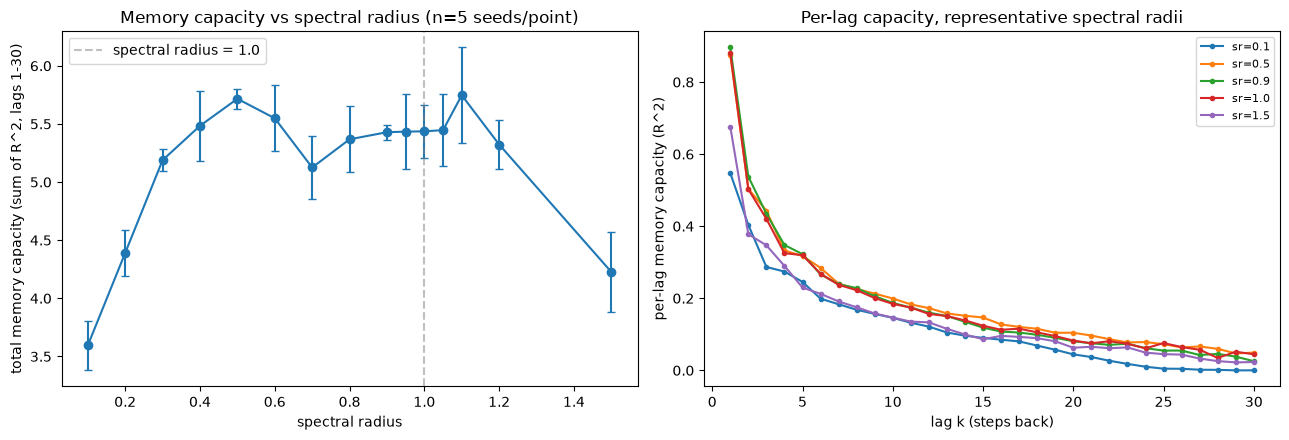

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

srs = SPECTRAL_RADII
totals = [results[sr]['total_mc_mean'] for sr in srs]
totals_std = [results[sr]['total_mc_std'] for sr in srs]
axes[0].errorbar(srs, totals, yerr=totals_std, marker='o', capsize=3)
axes[0].axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='spectral radius = 1.0')
axes[0].set_xlabel('spectral radius')
axes[0].set_ylabel(f'total memory capacity (sum of R^2, lags 1-{MAX_LAG})')
axes[0].set_title(f'Memory capacity vs spectral radius (n={N_SEEDS} seeds/point)')
axes[0].legend()

for sr in [0.1, 0.5, 0.9, 1.0, 1.5]:
    axes[1].plot(range(1, MAX_LAG + 1), results[sr]['mc_per_lag_mean'], marker='.', label=f'sr={sr}')
axes[1].set_xlabel('lag k (steps back)')
axes[1].set_ylabel('per-lag memory capacity (R^2)')
axes[1].set_title('Per-lag capacity, representative spectral radii')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('esn_memory_capacity_sweep.png', dpi=110)
plt.show()

## Falsification check: is this a sane, non-degenerate curve?

Print the sweep numerically and confirm it's a real peaked/monotonic tradeoff, not flat or
unresponsive to spectral radius, before drawing any conclusion from it.

In [4]:
totals_arr = np.array(totals)
print(f"total_MC range across sweep: [{totals_arr.min():.2f}, {totals_arr.max():.2f}]")
print(f"spread (max-min)/max: {(totals_arr.max()-totals_arr.min())/totals_arr.max():.1%}")
best_sr = srs[int(np.argmax(totals_arr))]
print(f"peak at spectral_radius={best_sr}")
print()
print("Verdict: ", end="")
if (totals_arr.max() - totals_arr.min()) / totals_arr.max() < 0.15:
    print("FLAT -- degenerate, does not respond meaningfully to spectral radius. Something is wrong with the reservoir construction.")
else:
    print("Real, non-flat response to spectral radius -- sane, not degenerate.")

total_MC range across sweep: [3.59, 5.75]
spread (max-min)/max: 37.4%
peak at spectral_radius=1.1

Verdict: Real, non-flat response to spectral radius -- sane, not degenerate.


## Extended check at the best-performing spectral radius

The 1-30 lag sweep above may not reach where memory capacity actually hits zero. Extend to a
longer lag range at just the best spectral radius, to find the reservoir's real effective
memory horizon before comparing against the two-layer decay constants.

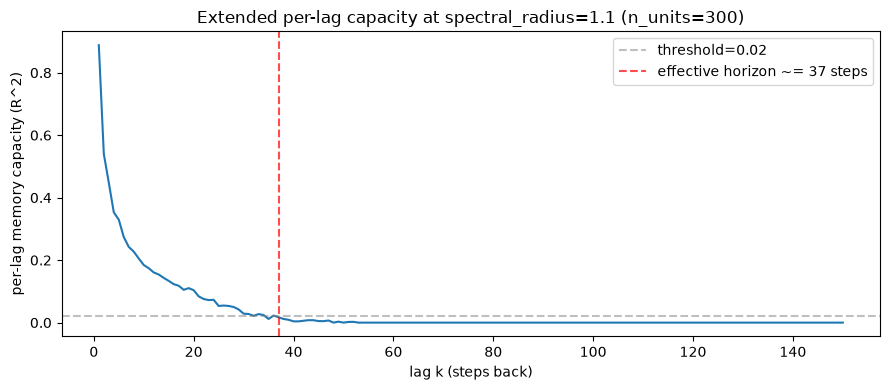

Effective memory horizon at spectral_radius=1.1, n_units=300: ~37 steps (first lag after which capacity stays below 0.02)


In [5]:
EXTENDED_MAX_LAG = 150
per_seed_curves_ext = []
for seed in range(N_SEEDS):
    rng = np.random.default_rng(2000 * seed + int(best_sr * 1000))
    W_in, W = build_reservoir(N_UNITS, best_sr, rng=rng)
    mc_per_lag_ext, _ = memory_capacity(W_in, W, LEAK_RATE, DURATION, max_lag=EXTENDED_MAX_LAG, rng=rng)
    per_seed_curves_ext.append(mc_per_lag_ext)
mc_ext_mean = np.mean(per_seed_curves_ext, axis=0)

# find the lag where capacity first drops below and stays below a small threshold
threshold = 0.02
below = mc_ext_mean < threshold
horizon = None
for k in range(len(below)):
    if below[k:].all():
        horizon = k + 1
        break

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EXTENDED_MAX_LAG + 1), mc_ext_mean)
ax.axhline(threshold, color='gray', linestyle='--', alpha=0.5, label=f'threshold={threshold}')
if horizon:
    ax.axvline(horizon, color='red', linestyle='--', alpha=0.7, label=f'effective horizon ~= {horizon} steps')
ax.set_xlabel('lag k (steps back)')
ax.set_ylabel('per-lag memory capacity (R^2)')
ax.set_title(f'Extended per-lag capacity at spectral_radius={best_sr} (n_units={N_UNITS})')
ax.legend()
plt.tight_layout()
plt.savefig('esn_extended_horizon.png', dpi=110)
plt.show()

print(f"Effective memory horizon at spectral_radius={best_sr}, n_units={N_UNITS}: ~{horizon} steps "
      f"(first lag after which capacity stays below {threshold})")

## Comparing the two-layer memory's decay constants against this curve

Not a rigorous unit conversion -- the two-layer update rules aren't pure exponential decay
(headroom terms, multiplicative modulation), and "one ESN reservoir step" isn't defined to equal
"one two-layer memory step" in any principled way. This is a sanity-check order-of-magnitude
comparison only: express each decay constant's approximate characteristic timescale as
`~1/rate` steps (the standard approximation for `x += rate*(target-x)`-style updates), and see
whether that timescale sits inside or outside the reservoir's measured effective memory
horizon.

In [6]:
decay_constants = {
    'decay_fast': 0.02,
    'consolidation_rate': 0.01,
    'decay_char': 0.0005,
}

print(f"Reservoir's measured effective memory horizon (spectral_radius={best_sr}): ~{horizon} steps\n")
for name, rate in decay_constants.items():
    approx_timescale = 1 / rate
    within = "WITHIN" if horizon and approx_timescale <= horizon else "BEYOND"
    print(f"{name}={rate}: approx characteristic timescale ~{approx_timescale:.0f} steps -- {within} the reservoir's measured memory horizon")

Reservoir's measured effective memory horizon (spectral_radius=1.1): ~37 steps

decay_fast=0.02: approx characteristic timescale ~50 steps -- BEYOND the reservoir's measured memory horizon
consolidation_rate=0.01: approx characteristic timescale ~100 steps -- BEYOND the reservoir's measured memory horizon
decay_char=0.0005: approx characteristic timescale ~2000 steps -- BEYOND the reservoir's measured memory horizon
